In [12]:
### All-in-One Python Script (simulate → SQL → forecast)

In [ ]:
# the code shows an end-to-end forecasting pipeline like a telecom would use—starting from raw network “events,” turning them into 
# clean time-series aggregates, and then building a forecast. That matters because real BT-style forecasting doesn’t begin with tidy data; 
# it begins with messy, granular logs. Your project proves you can (1) simulate or ingest raw events, (2) engineer robust aggregates with SQL, 
# and (3) model demand with a defendable, auditable approach.


In [11]:
# Adds a headline/comment so readers know this is an all-in-one pipeline.

In [1]:
# file: bt_forecasting_pipeline.py
# Usage: python bt_forecasting_pipeline.py
import numpy as np
import pandas as pd
import sqlite3
from datetime import datetime, timedelta
from pathlib import Path

# ---- 0) Config
DB_PATH = Path("telecom_bt_demo.sqlite")
SEED = 42
HOURS_BACK = 14 * 24          # 14 days of hourly-ish events
N_MSISDN = 50_000             # population
N_EVENTS = 250_000            # raw events
REGIONS = ["North", "South", "East", "West", "London"]
CELLS_PER_REGION = 120        # 5 * 120 = 600 cells

np.random.seed(SEED)

# Simulate dimensions: cell → region
cells = []
cell_id = 1
for r in REGIONS:
    for _ in range(CELLS_PER_REGION):
        cells.append((cell_id, r))
        cell_id += 1
dim_cell = pd.DataFrame(cells, columns=["cell_id", "region"])




In [2]:
# Simulate raw mobile data session events
now = datetime.utcnow().replace(minute=0, second=0, microsecond=0)
event_times = np.random.randint(0, HOURS_BACK, size=N_EVENTS)
event_start = [now - timedelta(hours=int(h)) for h in event_times]
event_dur_min = np.random.randint(1, 90, size=N_EVENTS)
event_end = [s + timedelta(minutes=int(d)) for s, d in zip(event_start, event_dur_min)]

msisdn = np.random.randint(7_000_000_000, 7_999_999_999, size=N_EVENTS)
cell_ids = np.random.randint(1, len(dim_cell) + 1, size=N_EVENTS)

# Base usage (MB) with time-of-day + day-of-week patterns
base = np.random.exponential(scale=40, size=N_EVENTS)
tod = np.array([s.hour for s in event_start])
dow = np.array([s.weekday() for s in event_start])

# evening prime-time uplift + weekend uplift
tod_factor = 0.6 + 0.8 * ((tod >= 18) & (tod <= 23))
dow_factor = 0.8 + 0.3 * ((dow == 5) | (dow == 6))
data_mb = base * tod_factor * dow_factor
data_mb = np.clip(data_mb, 0.1, None)

plan_type = np.random.choice(["Prepaid", "Postpaid", "SME", "Enterprise"], size=N_EVENTS, p=[0.35,0.45,0.12,0.08])

raw = pd.DataFrame({
    "msisdn": msisdn,
    "data_mb": data_mb,
    "cell_id": cell_ids,
    "event_start": event_start,
    "event_end": event_end,
    "plan_type": plan_type
})


/var/folders/9v/h89__8_509j7v8w0ylfs51zc0000gn/T/ipykernel_56837/2704525478.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().replace(minute=0, second=0, microsecond=0)


In [14]:
# High-level narrative of the project’s purpose (raw → SQL → forecast).
# Create SQLite DB and load tables
if DB_PATH.exists():
    DB_PATH.unlink()

con = sqlite3.connect(DB_PATH)
raw.to_sql("raw_mobile_data_events", con, index=False)
dim_cell.to_sql("dim_cell_tower", con, index=False)



600

In [5]:
# Imports + config (DB path, seeds, horizons). Also defines core parameters and the cell-to-region dimension used later.

# SQL: hourly aggregation per region
sql_usage_hourly = """
CREATE TABLE usage_hourly_region AS
SELECT
  DATETIME(STRFTIME('%Y-%m-%d %H:00:00', event_start)) AS hour,
  d.region AS region,
  SUM(r.data_mb) AS total_data_mb,
  COUNT(DISTINCT r.msisdn) AS active_users
FROM raw_mobile_data_events r
JOIN dim_cell_tower d USING (cell_id)
GROUP BY 1, 2
ORDER BY 1, 2;
"""
con.execute("DROP TABLE IF EXISTS usage_hourly_region;")
con.execute(sql_usage_hourly)
con.commit()

In [6]:
# Simulates raw session events (start/end times, MB, cell, plan) and bakes in time-of-day/week patterns; packs into a DataFrame.

# Pull aggregated data to pandas (sum across all regions)
df = pd.read_sql_query("""
SELECT hour, SUM(total_data_mb) AS total_mb, SUM(active_users) AS active_users
FROM usage_hourly_region
GROUP BY 1
ORDER BY 1
""", con, parse_dates=["hour"])

# Ensure regular hourly index
df = df.set_index("hour").asfreq("H").fillna(method="ffill")

/var/folders/9v/h89__8_509j7v8w0ylfs51zc0000gn/T/ipykernel_56837/1238102194.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index("hour").asfreq("H").fillna(method="ffill")
/var/folders/9v/h89__8_509j7v8w0ylfs51zc0000gn/T/ipykernel_56837/1238102194.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.set_index("hour").asfreq("H").fillna(method="ffill")


In [7]:
# Backtesting split: everything up to split is train, last 7 days are test.

# Train/validation split (last 7 days as test)
split_point = df.index.max() - pd.Timedelta(days=7)
train = df.loc[df.index <= split_point].copy()
test  = df.loc[df.index >  split_point].copy()


In [8]:
# Fits SARIMAX (seasonal ARIMA with 24-hour seasonality); generates test-set forecasts; computes MAPE.

# Forecast with SARIMAX (statsmodels)
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Simple seasonal hourly model (daily seasonality = 24)
y = train["total_mb"]
model = SARIMAX(
    y,
    order=(1,1,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
res = model.fit(disp=False)

# Forecast horizon = length of test
n = len(test)
pred = res.get_forecast(steps=n)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

# Combine for evaluation
fcst = pd.DataFrame({
    "actual": test["total_mb"],
    "forecast": pred_mean.values
}, index=test.index)

mape = (abs(fcst["actual"] - fcst["forecast"]) / fcst["actual"]).mean() * 100


python(64625) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [9]:
# Save outputs: Saves tidy CSVs (full series + forecast window) and prints paths/metrics.
DB_PATH_STR = str(DB_PATH.resolve())
df.to_csv("usage_hourly_all_regions.csv", index=True)
fcst.to_csv("forecast_hourly_next_7d.csv", index=True)

print(f"SQLite DB created: {DB_PATH_STR}")
print("usage_hourly_all_regions.csv and forecast_hourly_next_7d.csv saved.")
print(f"Test MAPE: {mape:.2f}%")

SQLite DB created: /Users/a.afenyiviolino/Desktop/telecom_bt_demo.sqlite
usage_hourly_all_regions.csv and forecast_hourly_next_7d.csv saved.
Test MAPE: 78.08%


Plot saved: bt_hourly_forecast.png


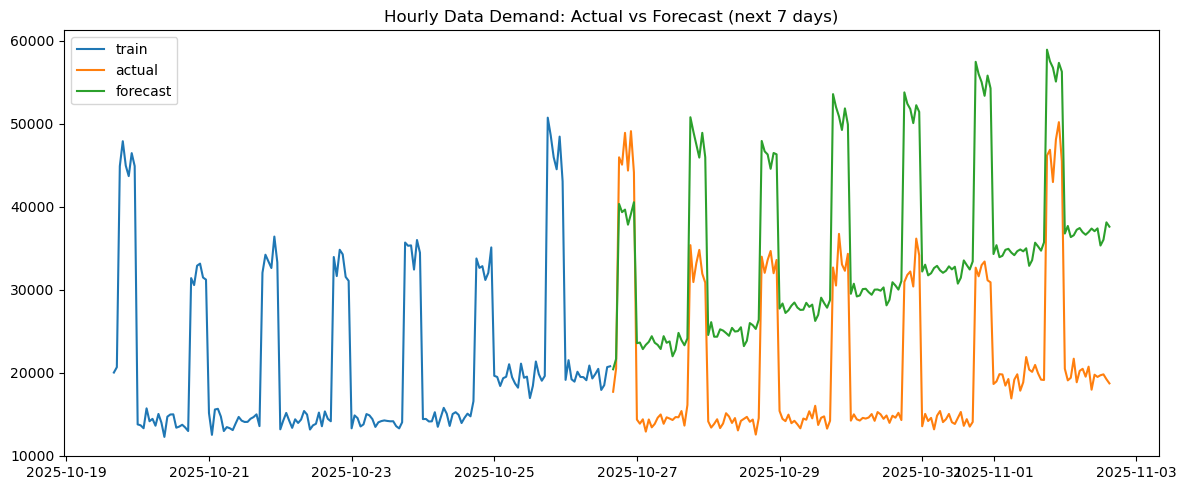

In [13]:
# Plots the final figure: train vs actuals (test) vs forecast; saves PNG.


# Optional: plot (saved to PNG)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train.index, train["total_mb"], label="train")
plt.plot(test.index, test["total_mb"], label="actual")
plt.plot(fcst.index, fcst["forecast"], label="forecast")
plt.title("Hourly Data Demand: Actual vs Forecast (next 7 days)")
plt.legend()
plt.tight_layout()
plt.savefig("bt_hourly_forecast.png")
print("Plot saved: bt_hourly_forecast.png")

con.close()


In [ ]:
# This chart shows how my model behaves on unseen data. The blue line is the history I trained on, the orange line is the real demand in the holdout 
# week, and the green line is my forecast for that same period. I’m looking for estimates to track the shape and daily peaks and troughs, 
# without huge misses. If the green line hugs the orange line, my features and seasonality choice are working. If it drifts or lags at peaks, 
# I’d revisit aggregation windows, add calendar effects, or tune SARIMAX orders.
